In [2]:
import h5py
import halotools
import os
import copy
import warnings
import numpy as np
import math
from astropy.modeling import Fittable1DModel, Parameter,models,fitting
import pickle
import warnings
import numpy.ma as ma
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import spearmanr,kendalltau,pearsonr,ks_2samp
import palettable
import deepdish as dd
import matplotlib.cm as cm

from matplotlib.collections import LineCollection
from photutils.isophote import EllipseGeometry
from photutils.aperture import EllipticalAperture,EllipticalAnnulus
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from matplotlib import colors
from astroML.stats import binned_statistic_2d
from scipy.ndimage.filters import gaussian_filter
from sklearn.linear_model import LinearRegression

from astropy.utils.console import ProgressBar
from astropy.table import QTable,hstack
plt.rc('text', usetex=True)
rcParams.update({'axes.linewidth': 1.5})
rcParams.update({'xtick.direction': 'in'})
rcParams.update({'ytick.direction': 'in'})
rcParams.update({'xtick.minor.visible': 'True'})
rcParams.update({'ytick.minor.visible': 'True'})
rcParams.update({'xtick.major.pad': '7.0'})
rcParams.update({'xtick.major.size': '8.0'})
rcParams.update({'xtick.major.width': '1.5'})
rcParams.update({'xtick.minor.pad': '7.0'})
rcParams.update({'xtick.minor.size': '4.0'})
rcParams.update({'xtick.minor.width': '1.5'})
rcParams.update({'ytick.major.pad': '7.0'})
rcParams.update({'ytick.major.size': '8.0'})
rcParams.update({'ytick.major.width': '1.5'})
rcParams.update({'ytick.minor.pad': '7.0'})
rcParams.update({'ytick.minor.size': '4.0'})
rcParams.update({'ytick.minor.width': '1.5'})
rcParams.update({'axes.titlepad': '10.0'})
rcParams.update({'font.size': 35})

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_37915/2620347147.py:28: DeprecationWarning: Please use `gaussian_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter


In [3]:
fig_dir="/Users/xushuo/work/Papers/CenvsSat/Figure/"
data_dir='/Users/xushuo/work/Submit/CenvsSat/Data/'

In [4]:
with open(data_dir+"galaxies_tng300_072_hmc_13_aperture_mass.txt",'rb') as f: 
    tab=pickle.load(f)
mask=(tab['proj']=='xy')
tab1=tab[mask]

In [5]:
with open(data_dir+"galaxies_tng300_072_hmc_13_richness_satellite_mass.txt",'rb') as f: 
    tab_rich0=pickle.load(f)

In [6]:
with open(data_dir+"galaxies_tng300_072_hmc_13_cylinder_richness_satellite_mass.txt",'rb') as f: 
    tab_rich=pickle.load(f)

In [7]:
tab2=hstack([tab[mask],tab_rich0[tab_rich0.colnames[2:]],tab_rich[tab_rich.colnames[2:]]])

In [8]:
def topNselect(data,name,number):
    data_meta=data.group_by(name)
    data0=data_meta[-number::]
    return data0
def topNoutselect(data,name1,name2,number):
    data_meta=data.group_by(np.log10(data[name1]-data[name2]))
    data0=data_meta[-number::]
    return data0
def linear1d(x,a,b):
    return a*x+b
def mpeakfind(tab,bin_num=30):
    numb,bins=np.histogram(tab,bins=bin_num)
    max_value=max(numb)
    max_index=list(numb).index(max_value)
    mpeak=bins[max_index]
    return mpeak
def resample_list(tab):
    length=len(tab)
    list0=np.random.randint(length,size=length)
    return tab[list0]

In [9]:
cmap1=palettable.lightbartlein.diverging.BlueDarkRed18_10.mpl_colormap

In [11]:
with open(data_dir+'galaxies_tng300_072_hmc_lensing_prof.txt','rb') as f:
    lensing_cat=pickle.load(f)

In [12]:
logrp_bins = np.linspace(-1,1.5,20)
rp_bins = 10**logrp_bins
logrp_mids = 0.5*(logrp_bins[:-1] + logrp_bins[1:])

In [13]:
def bootstrap_ratio_lensing(gal_num_upp,gal_num_down,rp_bins,times=5000):
    ratio_list=[]
    for ii in range(times):
        gal_rand_upp=resample_list(gal_num_upp)
        lens_tab=[]
        for i in gal_rand_upp:
            lens_tab.append(lensing_cat[i])
        lens_upp=np.mean(lens_tab,axis=0)
        gal_rand_down=resample_list(gal_num_down)
        lens_tab=[]
        for i in gal_rand_down:
            lens_tab.append(lensing_cat[i])
        lens_down=np.mean(lens_tab,axis=0)
        ratio_list.append(lens_down/lens_upp)
    median=[]
    upper=[]
    lower=[]
    for j in range(len(rp_bins)-1):
        median.append(np.percentile(np.asarray(ratio_list).T[j],50))
        upper.append(np.percentile(np.asarray(ratio_list).T[j],84))
        lower.append(np.percentile(np.asarray(ratio_list).T[j],16))
    return np.asarray(median),np.asarray(upper),np.asarray(lower)

In [14]:
def venn_diagram_test_lensing_ratio(data,name1,name2,top_numb):
    if 'out' in name2:
        ydata=np.log10(data['aper_100_gal']-data['aper_50_gal'])
        topNout=topNoutselect(data,'aper_100_gal','aper_50_gal',top_numb)
        mask_l=(ydata>=np.min(np.log10(topNout['aper_100_gal']-topNout['aper_50_gal'])))
    else:
        ydata=np.log10(data[name2])
        topNout=topNselect(data,name2,top_numb)
        mask_l=(ydata>=np.min(np.log10(topNout[name2])))
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        xdata=np.log10(data[name1])
    mask_h1=(xdata>np.min(np.log10(topNselect(data,name1,top_numb)[name1])))
    mask_h2=(xdata==np.min(np.log10(topNselect(data,name1,top_numb)[name1])))
    index_list=np.where(mask_h2==True)[0]
    true_num=top_numb-len(xdata[mask_h1])
    array=np.zeros(len(index_list))
    array[:true_num]=1
    np.random.shuffle(array)
    for j in range(len(index_list)):
        index=index_list[j]
        mask_h2[index]=mask_h2[index]&bool(array[j])
    mask_h=mask_h1|mask_h2
    mask_up=mask_l&(~mask_h)
    mask_down=mask_h&(~mask_l)
    mask_cro=mask_h&mask_l
    up_data=data[mask_up]
    down_data=data[mask_down]
    up_gal_num=up_data['gal_num']
    down_gal_num=down_data['gal_num']
    median,upper,lower=bootstrap_ratio_lensing(up_gal_num,down_gal_num,rp_bins,times=3000)
    return median,upper,lower

In [15]:
with open(data_dir+"galaxies_tng300_072_mah_hmc.txt",'rb') as f: 
    tab_mah=pickle.load(f)

In [17]:
mpeak_hist=[[],]
gal_num_exl=[]
for gal_num in range(3388):
    if (len(tab_mah[gal_num][0])>0):
        xdata=np.flip(np.append([72],tab_mah[gal_num][0].astype(np.int64)))
        ydata=np.flip(np.append([tab2['mass_halo'][gal_num]],tab_mah[gal_num][1]*1e10/0.6774))
        xdata0=[xdata[0],]
        ydata0=[ydata[0],]
        for i in range(1,len(xdata)):
            xdata0.append(xdata[i])
            if ydata[i]>ydata0[i-1]:
                ydata0.append(ydata[i])
            else:
                ydata0.append(ydata0[i-1])
    else:
        gal_num_exl.append(gal_num)
        xdata0=[None]
        ydata0=[None]
    mpeak_hist.append([xdata0,ydata0])
del mpeak_hist[0]
mask_exl=(tab2['aper_100_gal']>0)
for i in gal_num_exl:
    mask_exl=mask_exl&(tab2['gal_num']!=i)


In [18]:
mask1=(tab2['c_200c']<15)&mask_exl

In [24]:
top_numb=600
name_list=['richness_cut_r200_10','richness_cut_r200_10_xy_10','richness_cut_r200_10_xy_40']
label_list=[r'$\log\lambda_{\log M_\star>10,R_{200}}$',r'$\log\lambda_{\log M_\star>10,xy,10}$',r'$\log\lambda_{\log M_\star>10,xy,40}$']
median_list=[]
upper_list=[]
lower_list=[]
for i in range(len(name_list)):
    name1=name_list[i]
    name2='out_50_100_gal'
    median,upper,lower=venn_diagram_test_lensing_ratio(tab2[mask1],name1,name2,top_numb)
    median_list.append(median)
    upper_list.append(upper)
    lower_list.append(lower)

In [21]:
def medNselect(data,name,numb1,numb2):
    data_meta=data.group_by(name)
    if numb1!=0:
        data0=data_meta[-numb2:-numb1:]
    else:
        data0=data_meta[-numb2::]
    return data0

In [22]:
def medN_test_lensing_ratio(data,name1,name2,numb1,numb2):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        xdata=np.log10(data[name1])
    mask_h1=(xdata>np.min(np.log10(medNselect(tab2[mask1],name1,numb1,numb2)[name1])))&(xdata<np.max(np.log10(medNselect(tab2[mask1],name1,numb1,numb2)[name1])))
    mask_h2=(xdata==np.min(np.log10(medNselect(tab2[mask1],name1,numb1,numb2)[name1])))|(xdata==np.max(np.log10(medNselect(tab2[mask1],name1,numb1,numb2)[name1])))
    index_list=np.where(mask_h2==True)[0]
    true_num=top_numb-len(xdata[mask_h1])
    array=np.zeros(len(index_list))
    array[:true_num]=1
    np.random.shuffle(array)
    for j in range(len(index_list)):
        index=index_list[j]
        mask_h2[index]=mask_h2[index]&bool(array[j])
    mask_h=mask_h1|mask_h2
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        xdata=np.log10(data[name2])
    mask_h1=(xdata>np.min(np.log10(medNselect(tab2[mask1],name2,numb1,numb2)[name2])))&(xdata<np.max(np.log10(medNselect(tab2[mask1],name2,numb1,numb2)[name2])))
    mask_h2=(xdata==np.min(np.log10(medNselect(tab2[mask1],name2,numb1,numb2)[name2])))|(xdata==np.max(np.log10(medNselect(tab2[mask1],name2,numb1,numb2)[name2])))
    index_list=np.where(mask_h2==True)[0]
    true_num=top_numb-len(xdata[mask_h1])
    array=np.zeros(len(index_list))
    array[:true_num]=1
    np.random.shuffle(array)
    for j in range(len(index_list)):
        index=index_list[j]
        mask_h2[index]=mask_h2[index]&bool(array[j])
    mask_h_0=mask_h1|mask_h2
    up_data=data[mask_h_0]
    down_data=data[mask_h]
    up_gal_num=up_data['gal_num']
    down_gal_num=down_data['gal_num']
    median,upper,lower=bootstrap_ratio_lensing(up_gal_num,down_gal_num,rp_bins,times=3000)
    return median,upper,lower

In [23]:
top_list=[0,200,400,800]
median_list_0=[]
upper_list_0=[]
lower_list_0=[]
for i in range(len(top_list)-1):
    numb1=top_list[i]
    numb2=top_list[i+1]
    name1='richness_cut_r200_10_xy_40'
    name2='richness_cut_r200_10'
    median,upper,lower=medN_test_lensing_ratio(tab2[mask1],name1,name2,numb1,numb2)
    median_list_0.append(median)
    upper_list_0.append(upper)
    lower_list_0.append(lower)

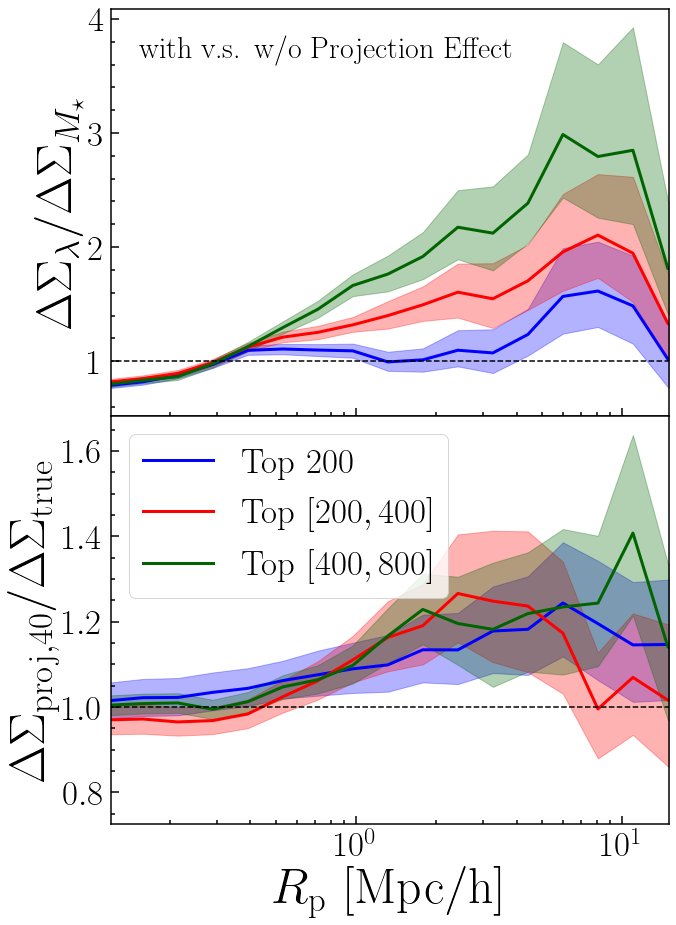

In [28]:
fig=plt.figure(figsize=(10,15))
gs = fig.add_gridspec(2,1, hspace=0, wspace=0)
ax1,ax2=gs.subplots(sharex='row')
color_list=['blue','red','darkgreen','purple','black','brown']
label_list=[r'$\log\lambda_{\log M_\star>10,R_{200}}$',r'$\log\lambda_{\log M_\star>10,xy,10}$',r'$\log\lambda_{\log M_\star>10,xy,40}$']
for i in range(len(name_list)):
    col=color_list[i]
    median=median_list[i]
    upper=upper_list[i]
    lower=lower_list[i]
    label=label_list[i]
    ax1.plot(10**logrp_mids,median,color=col,lw=3,label=label)
    ax1.fill_between(10**logrp_mids,upper,lower,color=col,alpha=0.3)
ax1.set_xscale('log')
ax1.set_xlim(0.12,15)

label_list=[r'\rm Top $200$',r'\rm Top $[200,400]$',r'\rm Top $[400,800]$']
for i in range(len(top_list)-1):
    col=color_list[i]
    median=median_list_0[i]
    upper=upper_list_0[i]
    lower=lower_list_0[i]
    label=label_list[i]
    ax2.plot(10**logrp_mids,median,color=col,lw=3,label=label)
    ax2.fill_between(10**logrp_mids,upper,lower,color=col,alpha=0.3)
ax2.set_xscale('log')
ax2.set_xlim(0.12,15)
ax2.plot(10**logrp_mids,1+0*logrp_mids,ls='--',color='black')
ax1.plot(10**logrp_mids,1+0*logrp_mids,ls='--',color='black')
ax1.set_ylabel(r'$\Delta\Sigma_{\lambda}/\Delta\Sigma_{M_\star}$', fontsize=50)
ax2.set_ylabel(r'$\Delta\Sigma_{\rm proj,40}/\Delta\Sigma_{\rm true}$', fontsize=50)
ax2.set_xlabel(r'$R_{\rm p} $  $\rm{[Mpc / h]}$', fontsize=50)
ax1.text(0.05,0.88,r'\rm with v.s. w/o Projection Effect',transform=ax1.transAxes,size=30)
ax2.legend()